# EDA

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings ('ignore')
%matplotlib inline 



In [3]:
df= pd.read_csv('cleaned_data/playstore_cleaned_data.csv')


In [4]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,day,month,year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [5]:
#to see is there any duplicated values eg in apps we will se is there any duplicated apps in there in thd playstore 
df.duplicated('App')

0        False
1        False
2        False
3        False
4        False
         ...  
10835    False
10836    False
10837    False
10838    False
10839    False
Length: 10840, dtype: bool

In [6]:
df[df.duplicated('App')].shape

(1181, 17)

conclusion = there are many duplicated apps (1181 duplicated apps )

In [ ]:
# now we will drop all the duplicates 
df.drop_duplicates(subset= ['App'], keep= 'first')  # keep ist means that if there is any ist record keep that and delete the 2nd record
# here we can write inplace = true also

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,day,month,year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,7,2017
10836,10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,6,7,2018
10837,10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up,20,1,2017
10838,10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,19,1,2015


 # explore data
 

we will se in our dataset which column is numerical and which is categorical..................


In Pandas, the data type for "Object" (text) is represented by the capital letter O (as in Object), SO THE NUMERICAL VALUES AS != O (NOT 0)

In [11]:
numerical_features = [ feature for feature in df.columns if df [feature].dtype != 'O']
categorical_features = [ feature for feature in df.columns if df [feature].dtype =='O']

#print column
print("we hahve {} numerical features ; {} ".format(len(numerical_features), numerical_features))
print("we hahve {} categorical features ; {} ".format(len(categorical_features), categorical_features))



we hahve 9 numerical features ; ['Unnamed: 0', 'Rating', 'Reviews', 'Size', 'Installs', 'Price', 'day', 'month', 'year'] 
we hahve 8 categorical features ; ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver'] 


In [13]:
# PROPORTION OF COUNT DATA ON THE CATEGORICAL COLUMNS 
for cols in categorical_features :
    print(df[cols].value_counts(normalize= True)*100) # here we will check the value counts 
    #normalize here to view our data in percent wise 
    print('-----------------------')

App
ROBLOX                                               0.083026
CBS Sports App - Scores, News, Stats & Watch Live    0.073801
ESPN                                                 0.064576
Duolingo: Learn Languages Free                       0.064576
8 Ball Pool                                          0.064576
                                                       ...   
FieldBi FR Offline                                   0.009225
Golden Dictionary (FR-AR)                            0.009225
FR: My Secret Pets!                                  0.009225
Learn To Draw Kawaii Characters                      0.009225
3D Color Pixel by Number - Sandbox Art Coloring      0.009225
Name: proportion, Length: 9659, dtype: float64
-----------------------
Category
FAMILY                 18.191882
GAME                   10.553506
TOOLS                   7.776753
MEDICAL                 4.271218
BUSINESS                4.243542
PRODUCTIVITY            3.911439
PERSONALIZATION         3.616236
COM

visualization of numerical counts 

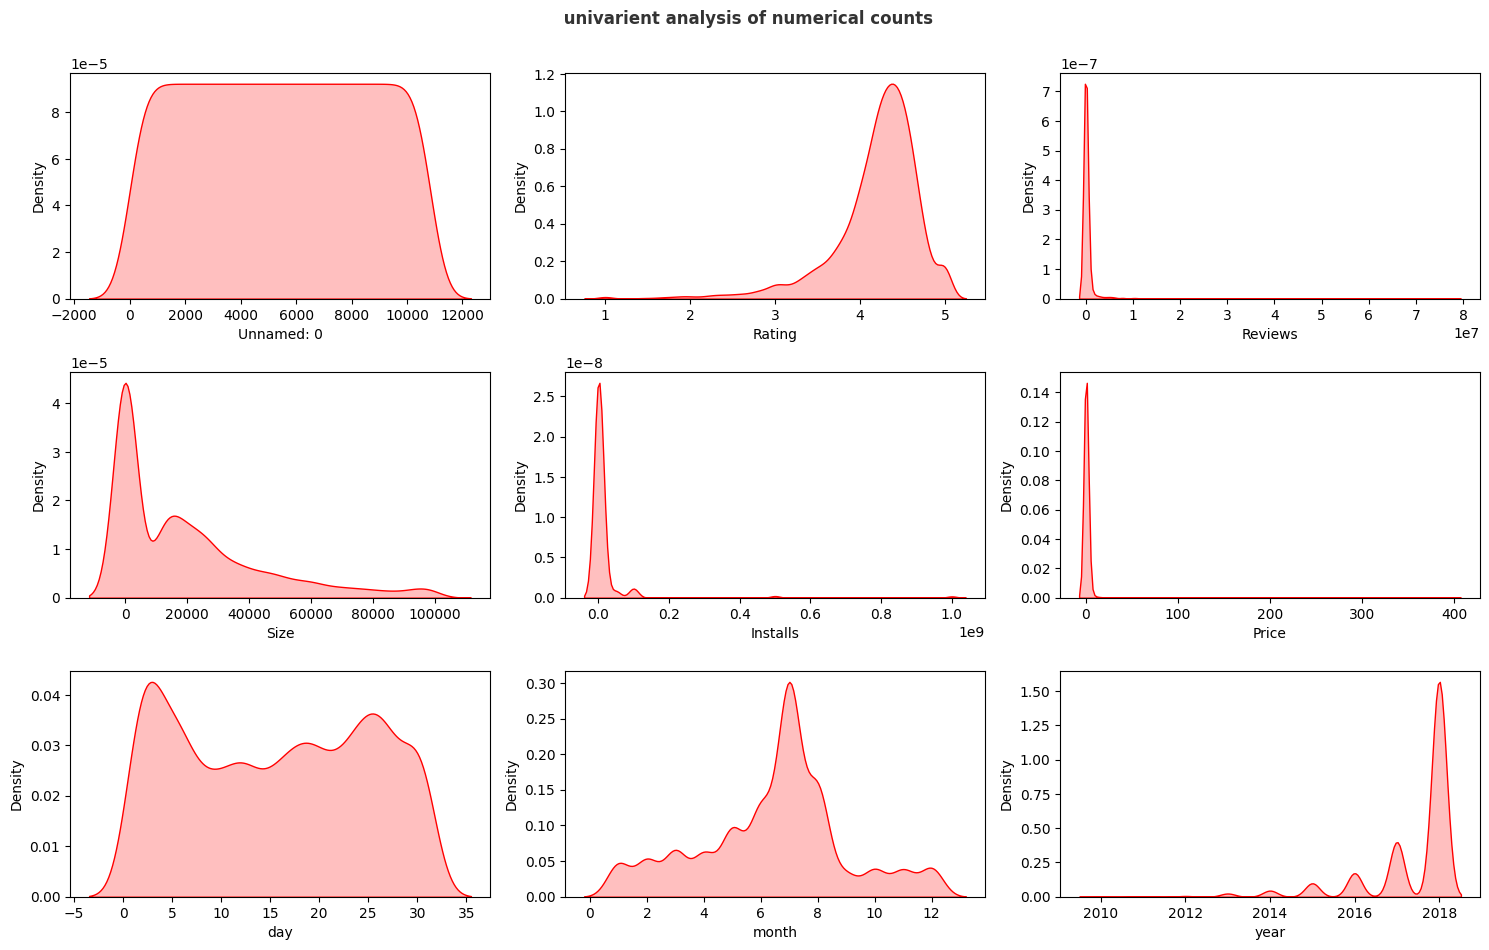

In [16]:
plt.figure(figsize=(15, 15))
plt.suptitle(' univarient analysis of numerical counts', fontsize = 12 , fontweight = 'bold', alpha= 0.8 , y = 1.)

for i in range (0 ,len(numerical_features)) :
    plt.subplot(5,3,i+1) 
    sns.kdeplot(x=df[numerical_features[i]], shade = True , color ='r')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()